<a href="https://colab.research.google.com/github/AgentBruh101/ML-Max-Temp-Weather-Predicter/blob/main/ML_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

 ------Weather Temperature Prediction with Custom LSTM--------

Loading and preprocessing weather data...
Dataset shape: (1461, 6)
Date range: 2012-01-01 00:00:00 to 2015-12-31 00:00:00
Features: ['precipitation', 'temp_max', 'temp_min', 'wind', 'weather_drizzle', 'weather_fog', 'weather_rain', 'weather_snow', 'weather_sun']
Processed data shape - X: (1453, 7, 9), y: (1453, 1)
Train: (1017, 7, 9), Validation: (217, 7, 9), Test: (219, 7, 9)

Creating base models:
Persistence Model - Test MSE: 0.0142, RMSE: 4.45°C
Linear Regression - Test MSE: 0.0081, RMSE: 3.36°C

Initializing Custom LSTM...
Input size: 9, Hidden size: 32, Output size: 1
Training our LSTM...
Epoch   0: Train Loss = 0.27340, Val Loss = 0.26546
Epoch  10: Train Loss = 0.01263, Val Loss = 0.00883
Epoch  20: Train Loss = 0.00806, Val Loss = 0.00706
Epoch  30: Train Loss = 0.00800, Val Loss = 0.00725
Epoch  40: Train Loss = 0.00783, Val Loss = 0.00726
Epoch  50: Train Loss = 0.00780, Val Loss = 0.00726
Epoch  60: Train Loss 

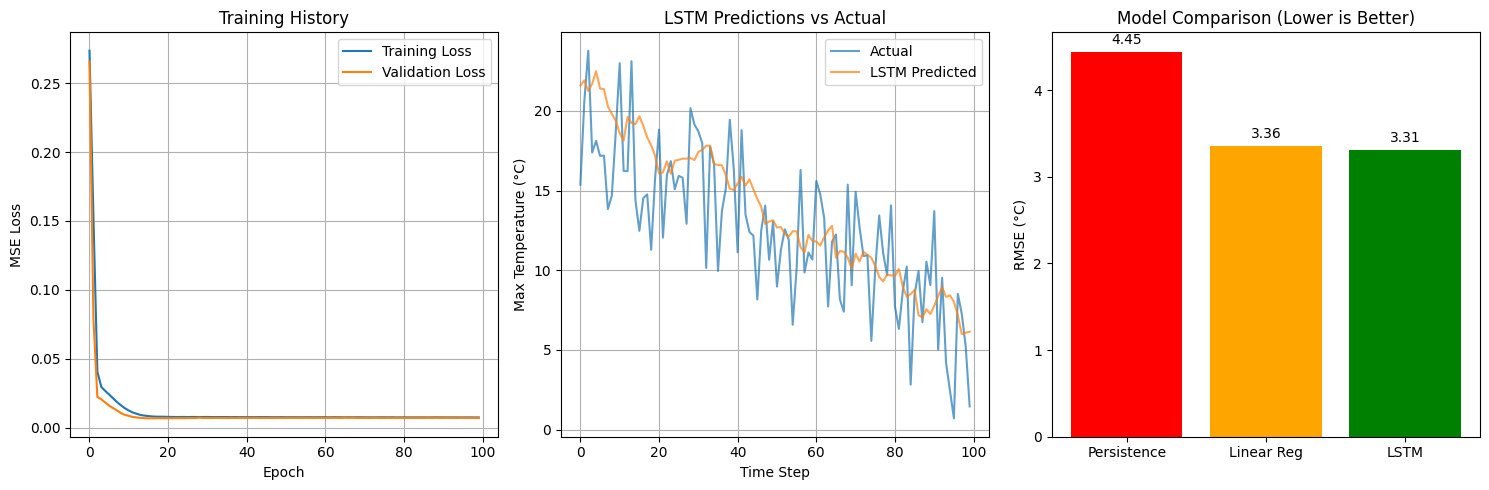

In [ ]:
#Importing necessary libaries

############################################################
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import requests
import io
###########################################################


class CustomLSTM:
    # Our custom LSTM implementation from scratch


    def params(self):
      return {
            'forgetWeight': self.forgetWeight,
            'forgetBias': self.forgetBias,
            'inputWeight': self.inputWeight,
            'inputBias': self.inputBias,
            'cellWeight': self.cellWeight,
            'cellBias': self.cellBias,
            'outputGateWeight': self.outputGateWeight,
            'outputGateBias': self.outputGateBias,
            'finalWeight': self.finalWeight,
            'finalBias': self.finalBias
        }


    def __init__(self, input_size, hidden_size, output_size, sequence_length):
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.output_size = output_size
        self.sequence_length = sequence_length

        # Added for Adam Optimization
        self.t = 0
        self.beta1 = .9
        self.beta2 = .999
        self.epsilon = 1e-8

        # Initialize all weights and biases below


        #Adam Optimization Initialization
        self.m = {k: np.zeros_like(v) for k, v in self._params().items()}
        self.v = {k: np.zeros_like(v) for k, v in self._params().items()}


        # Forget gate parameters

        std = np.sqrt(1.0 / (hidden_size + input_size))
        self.forgetWeight = np.random.randn(hidden_size, hidden_size + input_size) * std
        self.forgetBias = np.ones((hidden_size, 1))

        # Input gate parameters

        self.inputWeight = np.random.randn(hidden_size, hidden_size +input_size) * std
        self.inputBias = np.zeros((hidden_size, 1))

        # Cell state parameters

        self.cellWeight = np.random.randn( hidden_size, hidden_size + input_size) * std
        self.cellBias = np.zeros((hidden_size, 1))

        # Output gate parameters

        self.outputGateWeight = np.random.randn(hidden_size, hidden_size + input_size) * std
        self.outputGateBias = np.zeros(( hidden_size, 1))

        # Output layer parameters

        self.finalWeight = np.random.randn(output_size, hidden_size) * std
        self.finalBias = np.zeros(( output_size, 1))

    def sigmoid(self, x):
        #Sigmoid activation function

        return 1 / (1 + np.exp(-np.clip(x, -250, 250)))

    def tanh(self, x):
        #Tanh activation function

        return np.tanh(x)

    def forward(self, X):
        # Forward pass through our LSTM


        #Note: X shape: (batch_size, sequence_length, input_size)
        #Note: Returns: outputs (batch_size, sequence_length, output_size)

        batch_size = X.shape[0]

        # Initialize the hidden and cell states

        hiddenState= np.zeros((batch_size, self.hidden_size))
        cellState= np.zeros((batch_size,  self.hidden_size))



        # Store values for backward pass
        self.store = {
            'X': X,
            'f':[], 'i':[], 'c_hat':[], 'c':[], 'o':[], 'h':[]
        }

        outputs = []

        for t in range(self.sequence_length):
            # Getting the current input

            currentInput = X[:, t, :]  # this is equal to: (batch_size, input_size)

            # Combining hidden states & inputs
            combined = np.concatenate([hiddenState, currentInput], axis=1)

            # The forget gate

            forgetValue = self.sigmoid(np.dot(combined,  self.forgetWeight.T) + self.forgetBias.T)

            # The input gate

            inputValue = self.sigmoid(np.dot( combined, self.inputWeight.T) + self.inputBias.T)

            # The  cell state
            candidateValue = self.tanh(np.dot(combined, self.cellWeight.T) + self.cellBias.T)

            # Cell state update
            cellState= forgetValue * cellState+ inputValue * candidateValue

            # Output gate
            outputValue = self.sigmoid(np.dot(combined, self.outputGateWeight.T) +self.outputGateBias.T)

            # Hidden state update
            hiddenState= outputValue * self.tanh(cellState)

            # Output
            currentPred = np.dot(hiddenState,  self.finalWeight.T) + self.finalBias.T

            # Store for backpropagation
            self.store['f'].append(forgetValue)
            self.store['i'].append(inputValue)
            self.store['c_hat'].append(candidateValue)
            self.store['c'].append(cellState.copy())
            self.store['o'].append(outputValue)
            self.store['h'].append(hiddenState.copy())

            outputs.append(currentPred)

        # Stack outputs along sequence dimension
        return np.stack(outputs,  axis=1)  # (batch_size, sequence_length, output_size)

    def backward(self, dY, learning_rate=0.01):

        # Calculating the backward pass

        batch_size = dY.shape[0]

        # Initialize gradients
        dforgetWeight = np.zeros_like(self.forgetWeight)
        dforgetBias = np.zeros_like(self.forgetBias)
        dinputWeight = np.zeros_like(self.inputWeight)
        dinputBias = np.zeros_like( self.inputBias)
        dcellWeight = np.zeros_like(self.cellWeight)
        dcellBias = np.zeros_like(self.cellBias)
        doutputGateWeight = np.zeros_like(self.outputGateWeight)
        doutputGateBias = np.zeros_like( self.outputGateBias)
        dfinalWeight = np.zeros_like(self.finalWeight)
        dfinalBias = np.zeros_like(self.finalBias)

        # Initialize next hidden and cell state gradients
        dhiddenStateNext = np.zeros((batch_size, self.hidden_size))
        dcellStateNext = np.zeros((batch_size, self.hidden_size))

        X = self.store['X']

        for t in reversed(range(self.sequence_length)):
            # Output layer gradients
            dY_t = dY[:, t, :]  # (batch_size, output_size)
            dfinalWeight += np.dot(dY_t.T, self.store['h'][t])
            dfinalBias += np.sum(dY_t, axis=0, keepdims=True).T

            # Backprop through output layer to hidden state
            dhiddenState = np.dot(dY_t, self.finalWeight) + dhiddenStateNext

            # Output gate gradients
            doutputGate = dhiddenState * self.tanh(self.store['c'][t])
            doutputGateRaw = doutputGate * self.store['o'][t] * (1 - self.store['o'][t])

            # Cell state gradients
            dcellState= dcellStateNext + dhiddenState * self.store['o'][t] * (1 - self.tanh(self.store['c'][t])**2)

            # Input gate and candidate gradients
            dinputGate= dcellState* self.store['c_hat'][t]
            dinputGateRaw = dinputGate* self.store['i'][t] * (1 - self.store['i'][t])

            dcellStateHat= dcellState* self.store['i'][t]
            dcellStateHatRaw = dcellStateHat* (1 - self.store['c_hat'][t]**2)

            # Forget gate gradients
            prev_cellState= self.store['c'][t-1] if t > 0 else np.zeros((batch_size, self.hidden_size))
            dforgetGate = dcellState* prev_cellState
            dforgetGateRaw = dforgetGate * self.store['f'][t] * (1 - self.store['f'][t])

            # Combined input for all gates
            currentInput = X[:, t, :]
            combined = np.concatenate([self.store['h'][t-1] if t > 0 else np.zeros((batch_size, self.hidden_size)), currentInput], axis=1)

            # Update gate parameter gradients
            dforgetWeight += np.dot(dforgetGateRaw.T, combined)
            dforgetBias += np.sum(dforgetGateRaw, axis=0, keepdims=True).T

            dinputWeight += np.dot(dinputGateRaw.T, combined)
            dinputBias += np.sum(dinputGateRaw, axis=0, keepdims=True).T

            dcellWeight += np.dot(dcellStateHatRaw.T, combined)
            dcellBias += np.sum(dcellStateHatRaw, axis=0, keepdims=True).T

            doutputGateWeight += np.dot(doutputGateRaw.T, combined)
            doutputGateBias += np.sum(doutputGateRaw, axis=0, keepdims=True).T

            # Backprop to previous time step
            dcombined = (np.dot(dforgetGateRaw, self.forgetWeight) +
                        np.dot(dinputGateRaw, self.inputWeight) +
                        np.dot( dcellStateHatRaw, self.cellWeight) +
                        np.dot(doutputGateRaw, self.outputGateWeight))

            dhiddenStateNext = dcombined[:, :self.hidden_size]
            dcellStateNext = self.store['f'][t] * dcellState

            # Preventing any exploding gradients
            for grad in [dforgetWeight, dinputWeight, dcellWeight,  doutputGateWeight, dfinalWeight, dforgetBias, dinputBias, dcellBias, doutputGateBias, dfinalBias]:

            np.clip(grad, -1, 1, out=grad)

        # Update parameters using SGD
        self.t += 1

        for name, grad, param in zip(names, grads, params):
          self.m[name] = self.beta1 * self.m[name] + (1 - self.beta1) * grad
          self.v[name] = self.beta2 * self.v[name] + (1 - self.beta2) * grad**2

          m_hat = self.m[name] / (1 - self.beta1**self.t)
          v_hat = self.v[name] / (1 - self.beta2**self.t)

          param -= learning_rate * m_hat / (np.sqrt(v_hat) + self.epsilon)

def load_weather_data():
    # Load & preprocess the weather data

    try:
        # Source for dataset

        url = "seattle-weather.csv"
        date['date'] = pd.to_datetime(data['date'])
        return data

        # Creating backup data if needed in case of any failures

        dates = pd.date_range('2012-01-01', '2015-12-31')
        np.random.seed(42)

        # Making realistic weather data as the backup

        n_samples = len(dates)
        base_temp = 15 + 10 * np.sin(2 * np.pi * np.arange(n_samples) / 365)

        weather_data = pd.DataFrame({
            'date': dates,
            'precipitation': np.random.exponential(2, n_samples),
            'temp_max': base_temp + np.random.normal(0, 3, n_samples) + np.random.normal(0, 2, n_samples).cumsum() * 0.1,
            'temp_min': base_temp - 5 + np.random.normal(0, 2, n_samples),
            'wind': np.random.exponential(3, n_samples),
            'weather': np.random.choice(['rain', 'sun', 'drizzle', 'fog', 'snow'], n_samples, p=[0.2, 0.5, 0.1, 0.15, 0.05])
        })

        return weather_data

    except Exception as e:
        print(f"Error loading data: {e}")

        # Creating "made up" data as the backup

        dates = pd.date_range('2012-01-01', '2015-12-31')
        np.random.seed(42)

        n_samples = len(dates)
        base_temp = 15 + 10 * np.sin(2 * np.pi * np.arange(n_samples) / 365)

        weather_data = pd.DataFrame({
            'date': dates,
            'precipitation': np.random.exponential(2, n_samples),
            'temp_max': base_temp + np.random.normal(0, 3, n_samples) + np.random.normal(0, 2, n_samples).cumsum() * 0.1,
            'temp_min': base_temp - 5 + np.random.normal(0, 2, n_samples),
            'wind': np.random.exponential(3, n_samples),
            'weather': np.random.choice(['rain', 'sun', 'drizzle', 'fog', 'snow'], n_samples, p=[0.2, 0.5, 0.1, 0.15, 0.05])
        })

        return weather_data

def preprocess_data(data, sequence_length=7):

    # Preprocessing the data for the LSTM training

    # One-hot encoding the weather column

    weather_encoded = pd.get_dummies( data['weather'], prefix='weather')
    data_encoded = pd.concat([data, weather_encoded], axis=1)

    # Select important features

    featureColumns = ['precipitation', 'temp_max', 'temp_min', 'wind'] + list(weather_encoded.columns)
    features = data_encoded[featureColumns].values

    # Normalizing those features

    feature_scaler = MinMaxScaler()
    featuresScaled = feature_scaler.fit_transform(features)

    # The target is next day's maximum temp

    target = data['temp_max'].values[1:].reshape(-1, 1)
    featuresScaled = featuresScaled[:-1]

    targetScaler = MinMaxScaler()
    targetScaled = targetScaler.fit_transform( target)

    # Create sequences
    X, y = [], []
    for i in range(len(featuresScaled) - sequence_length):
        X.append(featuresScaled[i:i+sequence_length])
        y.append(targetScaled[i+sequence_length])

    return np.array(X), np.array(y), feature_scaler, targetScaler, featureColumns

def create_baseline_models(X_train, y_train, X_test, y_test, targetScaler):
     # Creating and evaluating baseline models

    persistencePred = X_test[:, -1, 1:2]  # previous day's test max
    persistence_mse = mean_squared_error(y_test, persistencePred)

    # Linear reg model

    XTrainFlat = X_train.reshape(X_train.shape[0], -1)
    XTestFlat = X_test.reshape(X_test.shape[0], -1)

    LRModel = LinearRegression()
    LRModel.fit(XTrainFlat, y_train)

    LRPred = LRModel.predict(XTestFlat)
    LR_MSE = mean_squared_error(y_test, LRPred)

    # Converting back to original scale

    persistence_original = targetScaler.inverse_transform(persistencePred)
    LR_OG = targetScaler.inverse_transform(LRPred)
    yTestOriginal = targetScaler.inverse_transform(y_test)

    persistence_rmse = np.sqrt(mean_squared_error(yTestOriginal, persistence_original))
    LR_RMSE = np.sqrt(mean_squared_error(yTestOriginal, LR_OG))

    return {
        'persistence': {'mse': persistence_mse, 'rmse': persistence_rmse},
        'linear_regression': {'mse': LR_MSE, 'rmse': LR_RMSE},
        'predictions': {
            'persistence': persistence_original,
            'linear_regression': LR_OG
        }
    }

def main():

    print(" ------Weather Temperature Prediction with Custom LSTM--------\n")

    # Loading & preprocessing the data
    print("Loading and preprocessing weather data...")
    data = load_weather_data()
    print(f"Dataset shape: {data.shape}")
    print(f"Date range: {data['date'].min()} to {data['date'].max()}")

    sequence_length = 7

    X, y, featureScaler, targetScaler, featureColumns = preprocess_data(data, sequence_length)

    print(f"Features: {featureColumns}")
    print(f"Processed data shape - X: {X.shape}, y: {y.shape}")

    # Splitting the data in a timely manner

    trainSize = int(0.7 *  len(X))
    valSize = int(0.15 * len(X))

    X_train, X_val, X_test = X[:trainSize], X[trainSize:trainSize+valSize],  X[trainSize+valSize:]

    y_train, y_val, y_test =  y[:trainSize], y[trainSize:trainSize+valSize], y[trainSize+valSize:]

    print(f"Train: {X_train.shape}, Validation: {X_val.shape}, Test: {X_test.shape}")

    # Creating the base models

    print("\nCreating base models:")
    baselines = create_baseline_models( X_train, y_train, X_test,  y_test, targetScaler)

    print(f"Persistence Model - Test MSE: {baselines['persistence']['mse']:.4f}, RMSE: {baselines['persistence']['rmse']:.2f}°C")
    print(f"Linear Regression - Test MSE: {baselines['linear_regression']['mse']:.4f}, RMSE: {baselines['linear_regression']['rmse']:.2f}°C")

    # LSTM parameters
    input_size = X.shape[2]  # Number of features
    hidden_size = 32
    output_size = 1

    learning_rate = 0.05 #optimized learning rate
    epochs = 100    #optimized num of epochs
    batch_size = 32 #mini-batching

    # Initializing the LSTM

    print(f"\nInitializing Custom LSTM...")
    print(f"Input size: {input_size}, Hidden size: { hidden_size}, Output size: {output_size}")

    lstm = CustomLSTM(input_size, hidden_size, output_size, sequence_length)

    # Training

    print("Training our LSTM...")
    train_losses = []
    valLosses = []

    for epoch in range(epochs):

      # Shuffling data for every epoch

      indices = np.arange( X_train.shape[0])
      np.random.shuffle(indices)

      xTrainShuffled = X_train[indices]
      yTrainShuffled = y_train[indices]

      epochLoss = 0
      numBatches = 0


      #Loop for the batch

      for i in range(0, X_train.shape[0], batch_size):
        X_batch = xTrainShuffled[i:i+batch_size]
        y_batch = yTrainShuffled[i:i+batch_size]

      ###############################################################

        # Forward pass calculation step

        trainOutput = lstm.forward(X_batch)
        loss = mean_squared_error(y_batch, trainOutput[:, -1, :])
        epochLoss += loss
        numBatches += 1


        # Backward pass calculation step

        dYTrain = 2 * ( trainOutput[:, -1, :] - y_batch)
        dYTrainExpanded = np.zeros_like(trainOutput)

        dYTrainExpanded[:, -1, :] = dYTrain

        lstm.backward(dYTrainExpanded, learning_rate)

      # Calculating the average loss

      avgLoss = epochLoss/numBatches
      train_losses.append(avgLoss)


      # Validation

      valOutput = lstm.forward(X_val)
      valLoss= mean_squared_error( y_val, valOutput[:,  -1, :])

      #train_losses.append(train_losses)

      valLosses.append(valLoss)

      if epoch % 10 == 0:
          print(f"Epoch {epoch:3d}: Train Loss = {avgLoss:.5f}, Val Loss = {valLoss:.5f}")


                            # Final evaluation

    testOutput = lstm.forward( X_test)
    testPredScaled = testOutput[ :, -1, :]
    MSE = mean_squared_error(y_test,  testPredScaled)

    # Converting pred's back to original state
    testPredOriginal = targetScaler.inverse_transform(testPredScaled)
    yTestOriginal = targetScaler.inverse_transform(y_test)

    #RMSE

    RMSE = np.sqrt( mean_squared_error(yTestOriginal, testPredOriginal))

    # Some quick analysis

    print(f"\n-----Final Results------")
    print(f"Custom LSTM - Test MSE: {MSE:.4f}, RMSE: {RMSE:.2f}°C")
    print(f"Improvement over Linear Regression: {(baselines['linear_regression']['rmse'] - RMSE) / baselines['linear_regression']['rmse'] * 100:.1f}%")

    # Ploting the results
    plt.figure( figsize=( 15, 5))



################################################################################

                           # Plot 1: Training history

    plt.subplot(1, 3, 1)
    plt.plot(train_losses,  label='Training Loss')
    plt.plot(valLosses, label='Validation Loss')

    plt.xlabel('Epoch')
    plt.ylabel('MSE Loss')

    plt.title('Training History')
    plt.legend()
    plt.grid(True)

                          # Plot 2: Predictions vs Actual


    plt.subplot(1, 3, 2)
    plt.plot(yTestOriginal[:100], label='Actual', alpha=0.7)
    plt.plot(testPredOriginal[:100], label='LSTM Predicted', alpha=0.7)

    plt.xlabel('Time Step')
    plt.ylabel('Max Temperature (°C)')

    plt.title('LSTM Predictions vs Actual')
    plt.legend()
    plt.grid(True)

                            # Plot 3: Model comparison

    plt.subplot(1, 3, 3)

    models = ['Persistence', 'Linear Reg', 'LSTM']
    rmse_values = [baselines['persistence']['rmse'], baselines['linear_regression']['rmse'], RMSE]

    plt.bar(models, rmse_values, color=['red', 'orange', 'green'])
    plt.ylabel('RMSE (°C)')
    plt.title('Model Comparison (Lower is Better)')

    for i, v in enumerate(rmse_values):
        plt.text(i, v + 0.05, f'{v:.2f}', ha='center', va='bottom')

    plt.tight_layout()
    plt.savefig('weatherPredictionResults.png', dpi=300,  bbox_inches='tight')
    plt.show()

                      # Additional experiment log for analysis

    experiment_log = {
        'parameters': {
            'hidden_units': hidden_size,
            'learning_rate': learning_rate,
            'sequence_length': sequence_length,
            'epochs': epochs
        },
        'results': {
            'train_mse': train_losses[-1],
            'val_mse': valLosses[-1],
            'test_mse': MSE,
            'test_rmse': RMSE,
            'baseline_persistence_rmse': baselines['persistence']['rmse'],
            'baseline_LR_RMSE': baselines['linear_regression']['rmse']
        },
        'model': lstm
    }

    return experiment_log

if __name__ == "__main__":
    main()